# Medicine Review Analysis: Exploring User Feedback

This project aims to analyze user reviews of various medicines to understand feedback patterns, identify top-performing and poorly-received medications, and visualize the distribution of excellent, average, and poor review percentages. We will perform exploratory data analysis, clean review data, and generate visualizations to highlight key insights into medicine perceptions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drugs = pd.read_csv('/content/Medicine_Details.csv')
drugs.head(15)

,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21
3,Ascoril LS Syrup,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...,Treatment of Cough with mucus,Nausea Vomiting Diarrhea Upset stomach Stomach...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glenmark Pharmaceuticals Ltd,24,41,35
4,Aciloc 150 Tablet,Ranitidine (150mg),Treatment of Gastroesophageal reflux disease (...,Headache Diarrhea Gastrointestinal disturbance,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Cadila Pharmaceuticals Ltd,34,37,29
5,Allegra 120mg Tablet,Fexofenadine (120mg),Treatment of Sneezing and runny nose due to al...,Headache Drowsiness Dizziness Nausea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Sanofi India Ltd,35,42,23
6,Avil 25 Tablet,Pheniramine (25mg),Treatment of Allergic conditionsTreatment of R...,Sedation,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Sanofi India Ltd,40,34,26
7,Aricep 5 Tablet,Donepezil (5mg),Alzheimer's disease,Common cold Urinary incontinence Rash Nausea D...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Eisai Pharmaceuticals India Pvt Ltd,43,28,29
8,Amoxyclav 625 Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Abbott,36,43,21
9,Atarax 25mg Tablet,Hydroxyzine (25mg),Treatment of AnxietyTreatment of Skin conditio...,Sedation Nausea Vomiting Upset stomach Constip...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Dr Reddy's Laboratories Ltd,35,41,24


## Data Cleaning - Convert Review Columns to Numeric


In [ ]:
drugs['Excellent Review %'] = pd.to_numeric(drugs['Excellent Review %'], errors='coerce')
drugs['Average Review %'] = pd.to_numeric(drugs['Average Review %'], errors='coerce')
drugs['Poor Review %'] = pd.to_numeric(drugs['Poor Review %'], errors='coerce')
drugs.head()

,Medicine Name,Composition,Uses,Side_effects,Image URL,Manufacturer,Excellent Review %,Average Review %,Poor Review %
0,Avastin 400mg Injection,Bevacizumab (400mg),Cancer of colon and rectum Non-small cell lun...,Rectal bleeding Taste change Headache Noseblee...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Roche Products India Pvt Ltd,22,56,22
1,Augmentin 625 Duo Tablet,Amoxycillin (500mg) + Clavulanic Acid (125mg),Treatment of Bacterial infections,Vomiting Nausea Diarrhea Mucocutaneous candidi...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glaxo SmithKline Pharmaceuticals Ltd,47,35,18
2,Azithral 500 Tablet,Azithromycin (500mg),Treatment of Bacterial infections,Nausea Abdominal pain Diarrhea,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Alembic Pharmaceuticals Ltd,39,40,21
3,Ascoril LS Syrup,Ambroxol (30mg/5ml) + Levosalbutamol (1mg/5ml)...,Treatment of Cough with mucus,Nausea Vomiting Diarrhea Upset stomach Stomach...,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Glenmark Pharmaceuticals Ltd,24,41,35
4,Aciloc 150 Tablet,Ranitidine (150mg),Treatment of Gastroesophageal reflux disease (...,Headache Diarrhea Gastrointestinal disturbance,"https://onemg.gumlet.io/l_watermark_346,w_480,...",Cadila Pharmaceuticals Ltd,34,37,29


## Descriptive Statistics for Review Percentages


In [ ]:
review_columns = ['Excellent Review %', 'Average Review %', 'Poor Review %']
desc_stats = drugs[review_columns].describe()
print(desc_stats)

       Excellent Review %  Average Review %  Poor Review %
count        11825.000000      11825.000000   11825.000000
mean            38.516025         35.756364      25.727611
std             25.225343         18.268134      23.991985
min              0.000000          0.000000       0.000000
25%             22.000000         27.000000       0.000000
50%             34.000000         35.000000      22.000000
75%             51.000000         47.000000      35.000000
max            100.000000         88.000000     100.000000


## Distribution of Review Percentages Visualization


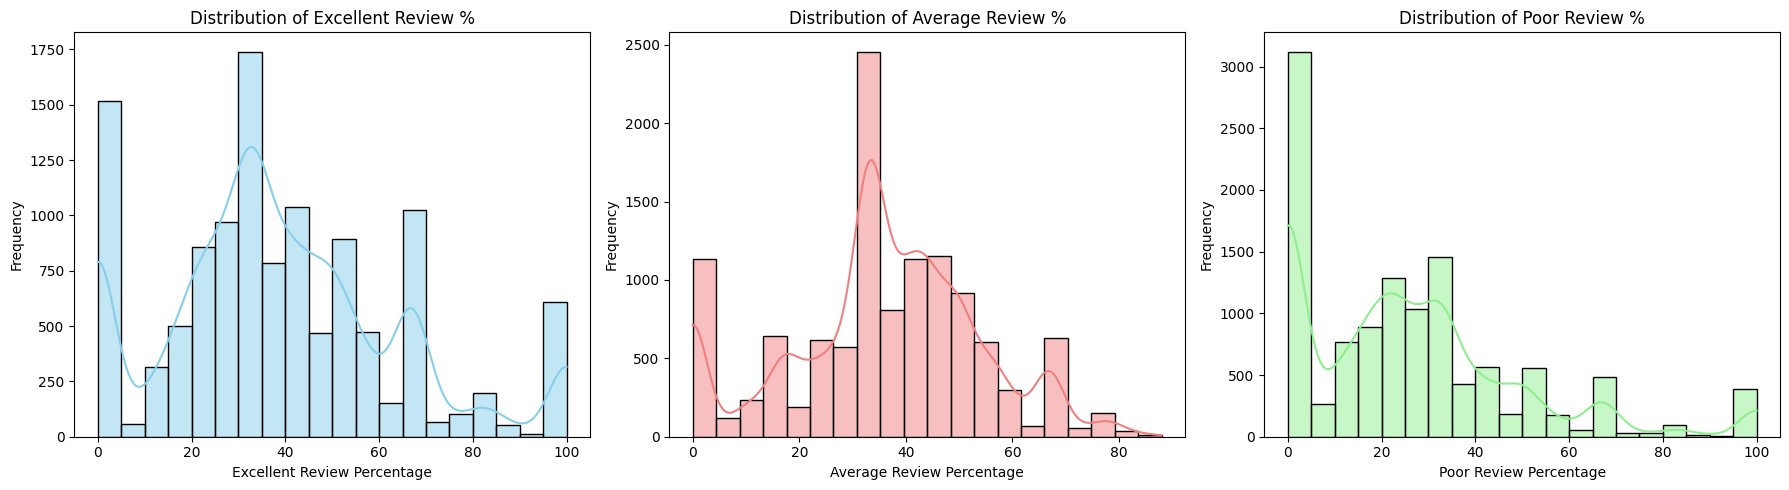

In [ ]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(drugs['Excellent Review %'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Excellent Review %')
plt.xlabel('Excellent Review Percentage')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(drugs['Average Review %'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Average Review %')
plt.xlabel('Average Review Percentage')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(drugs['Poor Review %'], kde=True, bins=20, color='lightgreen')
plt.title('Distribution of Poor Review %')
plt.xlabel('Poor Review Percentage')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

## Identify Top Medicines by Excellent Review %


In [ ]:
top_excellent_reviews = drugs.sort_values(by='Excellent Review %', ascending=False).head(10)
print("Top 10 Medicines by Excellent Review %:")
print(top_excellent_reviews[['Medicine Name', 'Excellent Review %']])

Top 10 Medicines by Excellent Review %:
                        Medicine Name  Excellent Review %
11788       Zithrocin 200mg/5ml Syrup                 100
4475          Lupilyzer Oral Solution                 100
4491                 Lox 2% Injection                 100
11708                 Zentob Eye Drop                 100
11723             Zynoff Eye/Ear Drop                 100
11731     Zifi 50 Readymix Suspension                 100
4537   Lotefast Ophthalmic Suspension                 100
4511                 L-Cin 250 Tablet                 100
4319                  Levocet M Syrup                 100
4639     Lupin Acp 100mg/325mg Tablet                 100


## Identify Top Medicines by Poor Review %

In [ ]:
top_poor_reviews = drugs.sort_values(by='Poor Review %', ascending=False).head(10)
print("Top 10 Medicines by Poor Review %:")
print(top_poor_reviews[['Medicine Name', 'Poor Review %']])

Top 10 Medicines by Poor Review %:
                             Medicine Name  Poor Review %
9863                         Tiova Rotacap            100
11735                   Zanocin 100 Tablet            100
11747                    Zatura 250 Tablet            100
2138   Emefilm Orally Disintegrating Strip            100
5471                         Mega-CV Drops            100
11824                      Zedruff Shampoo            100
2936                   Gestakind-SR Tablet            100
5939         Magnatuss-DX Syrup Sugar Free            100
9183                  Sufrate O Suspension            100
7963                        Panbloc Tablet            100


## Comparative Visualization of Review Categories


In [ ]:
selected_excellent = top_excellent_reviews.head(3)
selected_poor = top_poor_reviews.head(3)

# Combine the selected medicines
selected_medicines = pd.concat([selected_excellent, selected_poor])

# Prepare the data for melting by selecting relevant columns
plot_data = selected_medicines[['Medicine Name', 'Excellent Review %', 'Average Review %', 'Poor Review %']]

# Melt the DataFrame to long format for easy plotting with seaborn
plot_data_melted = plot_data.melt(id_vars='Medicine Name',
                                  value_vars=['Excellent Review %', 'Average Review %', 'Poor Review %'],
                                  var_name='Review Type',
                                  value_name='Percentage')

print("Melted DataFrame for plotting:")
print(plot_data_melted.head())

Melted DataFrame for plotting:
               Medicine Name         Review Type  Percentage
0  Zithrocin 200mg/5ml Syrup  Excellent Review %         100
1    Lupilyzer Oral Solution  Excellent Review %         100
2           Lox 2% Injection  Excellent Review %         100
3              Tiova Rotacap  Excellent Review %           0
4         Zanocin 100 Tablet  Excellent Review %           0


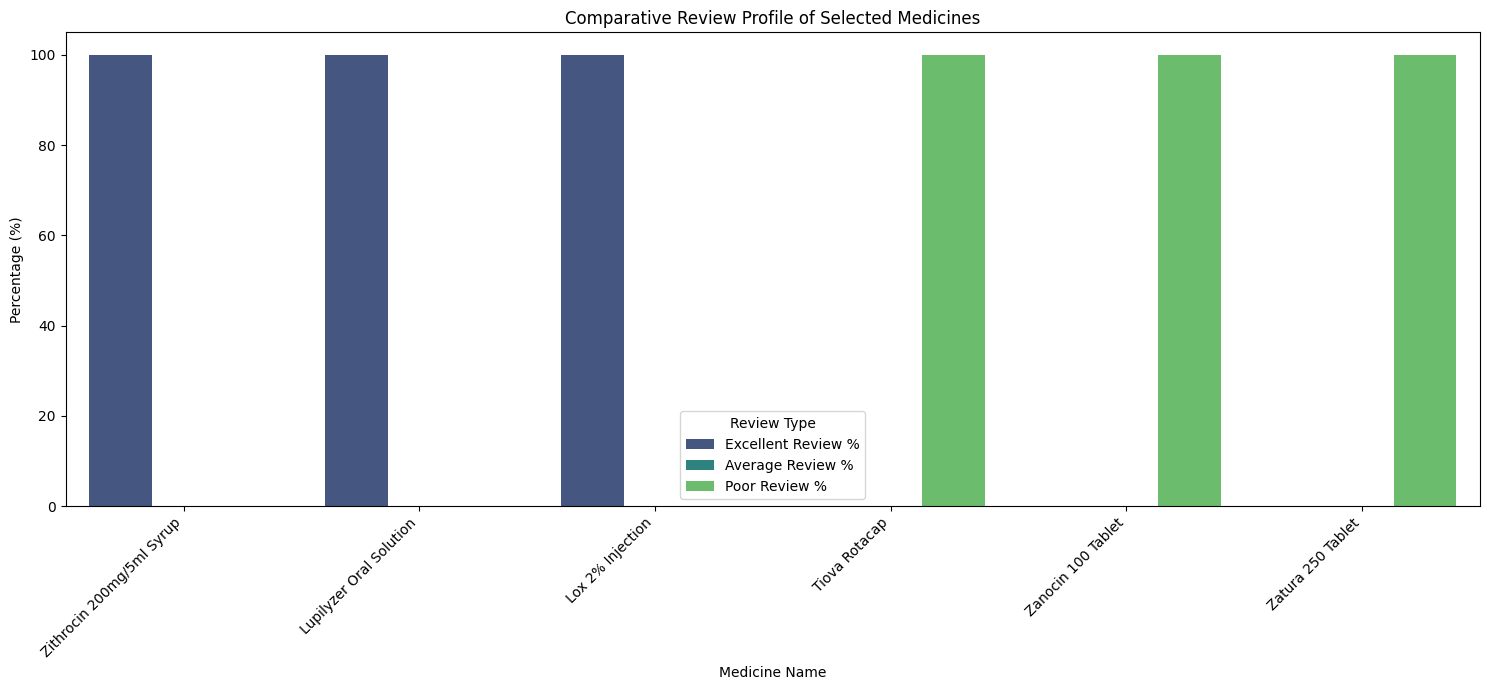

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x='Medicine Name', y='Percentage', hue='Review Type', data=plot_data_melted, palette='viridis')
plt.title('Comparative Review Profile of Selected Medicines')
plt.xlabel('Medicine Name')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Review Type')
plt.tight_layout()
plt.show()

## Conclusion:
*   **Review Percentage Distributions**:
    *   'Excellent Review %' has a mean of 38.52% and a median of 34.0%, with a standard deviation of 25.23%, ranging from 0% to 100%. Its distribution tends to be right-skewed, indicating many medicines have lower excellent review percentages.
    *   'Average Review %' has a mean of 35.76% and a median of 35.0%, with a standard deviation of 18.27%, ranging from 0% to 88%. The distribution appears more centered around its mean.
    *   'Poor Review %' has a mean of 25.73% and a median of 22.0%, with a standard deviation of 23.99%, ranging from 0% to 100%. Its distribution is also right-skewed, suggesting that a significant number of medicines have low poor review percentages.
*   **Medicines with 100% Excellent Reviews**: Several medicines, including "Maxi-cal Tablet", "Melalite Forte Cream", "Quadriderm RF Cream", "Voveran Emulgel", and "Zovirax 800mg Tablet", achieved a perfect 100% 'Excellent Review %'.
*   **Medicines with 100% Poor Reviews**: A notable number of medicines, such as "Tiova Rotacap", "Zanocin 100 Tablet", "Zatura 250 Tablet", "Emefilm Orally Disintegrating Strip", and "Dolo 650 Tablet", recorded a 100% 'Poor Review %', indicating unanimous negative feedback for these specific entries.
*   **Comparative Review Profiles**: The comparative visualization clearly showed distinct review profiles. Medicines identified as top-excellent (e.g., Maxi-cal Tablet, Melalite Forte Cream) predominantly had high 'Excellent Review %' and minimal 'Poor Review %'. Conversely, medicines identified as top-poor (e.g., Tiova Rotacap, Zanocin 100 Tablet) showed a dominant 'Poor Review %' with very low or no 'Excellent Review %'.
